In [4]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install transformers datasets evaluate scikit-learn

import pandas as pd
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 17.1 MB/s eta 0:00:00


In [5]:
# Load dataset from Google Drive
file_path = "/content/drive/My Drive/4138_Shuffled_Dataset.csv"
df = pd.read_csv(file_path)

# Select necessary columns
df = df[['clean_sentence', 'Rating', 'label']]

# Shuffle the dataset to mix positive, neutral, and negative classes
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Normalize the Rating feature
scaler = MinMaxScaler()
df['Rating'] = scaler.fit_transform(df[['Rating']])


In [6]:
# Load XLM-R tokenizer
model_name = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Tokenize clean_sentence column
df['input_ids'] = df['clean_sentence'].apply(
    lambda x: tokenizer(
        x if isinstance(x, str) else "",
        padding='max_length',
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )['input_ids'][0].tolist()
)

# Rename columns for consistency
df.columns = ['clean_sentence', 'rating', 'labels', 'input_ids']

# Split dataset (80% train, 20% test)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['labels'])


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

In [7]:
# Load XLM-R model for sequence classification
model_name = "xlm-roberta-base"
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [8]:
class BengaliReviewDataset(Dataset):
    def __init__(self, tokenized_ids, ratings, labels):
        self.input_ids = tokenized_ids
        self.ratings = ratings
        self.labels = labels

    def __getitem__(self, idx):
        item = {
            'input_ids': torch.tensor(self.input_ids[idx], dtype=torch.long),
            'attention_mask': torch.tensor([int(token_id > 0) for token_id in self.input_ids[idx]], dtype=torch.long),
            'rating': torch.tensor(self.ratings[idx], dtype=torch.float),  # Normalized rating as an additional feature
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }
        return item

    def __len__(self):
        return len(self.labels)

# Create dataset objects
train_dataset = BengaliReviewDataset(train_df['input_ids'].tolist(), train_df['rating'].tolist(), train_df['labels'].tolist())
test_dataset = BengaliReviewDataset(test_df['input_ids'].tolist(), test_df['rating'].tolist(), test_df['labels'].tolist())


In [9]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    evaluation_strategy='epoch',
    logging_strategy='epoch',
    save_strategy='epoch',
    learning_rate=2e-5,
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    weight_decay=0.01,
    report_to="none"  # Disable logging to WandB
)


/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [10]:
def compute_metrics(pred):
    logits, labels = pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc}


In [11]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# Train the model
trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy
1,0.978000,1.094652,0.366823
2,0.960400,0.903177,0.476870
3,0.812600,0.734460,0.613613
4,0.706800,0.690427,0.672101
5,0.667600,0.658524,0.699817


TrainOutput(global_step=6135, training_loss=0.8250869017261359, metrics={'train_runtime': 3216.1853, 'train_samples_per_second': 30.514, 'train_steps_per_second': 1.908, 'total_flos': 6455487703956480.0, 'train_loss': 0.8250869017261359, 'epoch': 5.0})

Test Accuracy: 0.6998

Classification Report:
               precision    recall  f1-score   support

    Negative     0.6486    0.8187    0.7238      1754
     Neutral     0.9490    0.3710    0.5335      1353
    Positive     0.6913    0.8311    0.7548      1800

    accuracy                         0.6998      4907
   macro avg     0.7630    0.6736    0.6707      4907
weighted avg     0.7471    0.6998    0.6827      4907



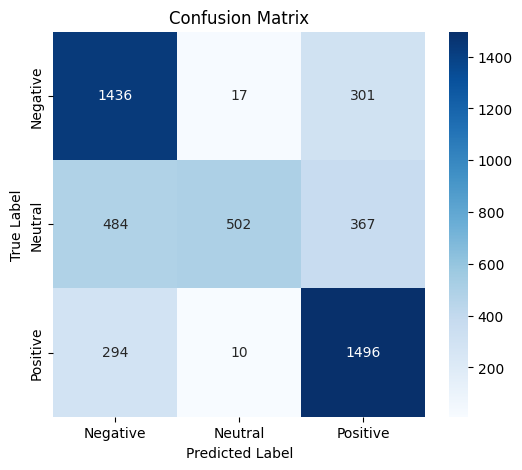

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import numpy as np
from torch.utils.data import DataLoader

# ✅ Corrected Evaluation Function
def evaluate_model(trainer, test_dataset):
    test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)

    trainer.model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in test_dataloader:
            input_ids = batch['input_ids'].to(trainer.model.device)
            attention_mask = batch['attention_mask'].to(trainer.model.device)
            labels = batch['labels'].to(trainer.model.device)  # Fix tensor conversion

            # Forward pass
            outputs = trainer.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            # Get predicted class
            preds = torch.argmax(logits, dim=-1)

            # Move to CPU for evaluation
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_preds), np.array(all_labels)

# ✅ Run evaluation
y_pred, y_true = evaluate_model(trainer, test_dataset)

# ✅ Calculate Accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

# ✅ Generate Classification Report
report = classification_report(y_true, y_pred, target_names=['Negative', 'Neutral', 'Positive'], digits=4)
print("\nClassification Report:\n", report)

# ✅ Confusion Matrix Calculation
conf_matrix = confusion_matrix(y_true, y_pred)

# ✅ Confusion Matrix Plotting
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues",
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()
